In [1]:
import numpy as np
import matplotlib.pyplot as plt

image = plt.imread('Mona_Lisa.jpg')

flat_image_0 = image[:,:,0].flatten()
flat_image_1 = image[:,:,1].flatten()
flat_image_2 = image[:,:,2].flatten()

image_shape=image.shape
image_shape

(1198, 792, 3)

In [2]:
correlation=[]
tx_range=range(-10, 11, 1)

for tx in tx_range:
    new_image=np.zeros(image_shape)
    
    if tx<0:
        new_image[:,0:tx,:]=image[:,-tx:,:]
    elif tx>0:
        new_image[:,tx:,:]=image[:,:-tx,:]
    else:
        new_image=image
    
    flat_newimage_0 = new_image[:,:,0].flatten()
    flat_newimage_1 = new_image[:,:,1].flatten()
    flat_newimage_2 = new_image[:,:,2].flatten()
    
    correlation.append([np.corrcoef(flat_image_0, flat_newimage_0)[0,1], 
                     np.corrcoef(flat_image_1, flat_newimage_1)[0,1],
                     np.corrcoef(flat_image_2, flat_newimage_2)[0,1],])

correlation=np.array(correlation).T

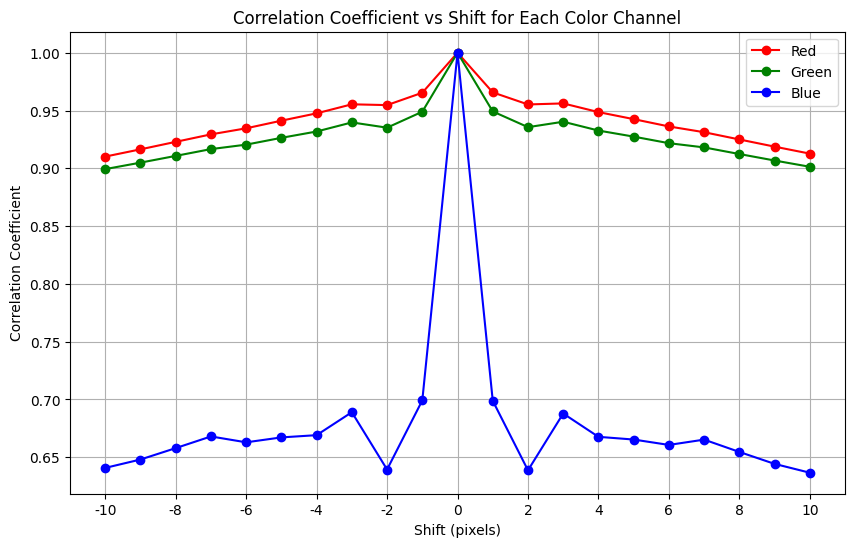

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(tx_range, correlation[0], 'r-', marker='o', label='Red')
plt.plot(tx_range, correlation[1], 'g-', marker='o', label='Green')
plt.plot(tx_range, correlation[2], 'b-', marker='o', label='Blue')

plt.title('Correlation Coefficient vs Shift for Each Color Channel')
plt.xlabel('Shift (pixels)')
plt.ylabel('Correlation Coefficient')
plt.xticks(ticks=range(-10, 11, 2), labels=range(-10, 11, 2))
plt.legend()
plt.grid(True)

plt.savefig('correlation_plot.png')
plt.show()

In [4]:
# no_of_bins=32
# count=np.zeros(no_of_bins)

# for i in range(image_shape[0]):
#     for j in range(image_shape[1]):
#         count[int(image[i,j,0]*no_of_bins/256)]+=1
        
# normalised_count=count/np.sum(count)

# count

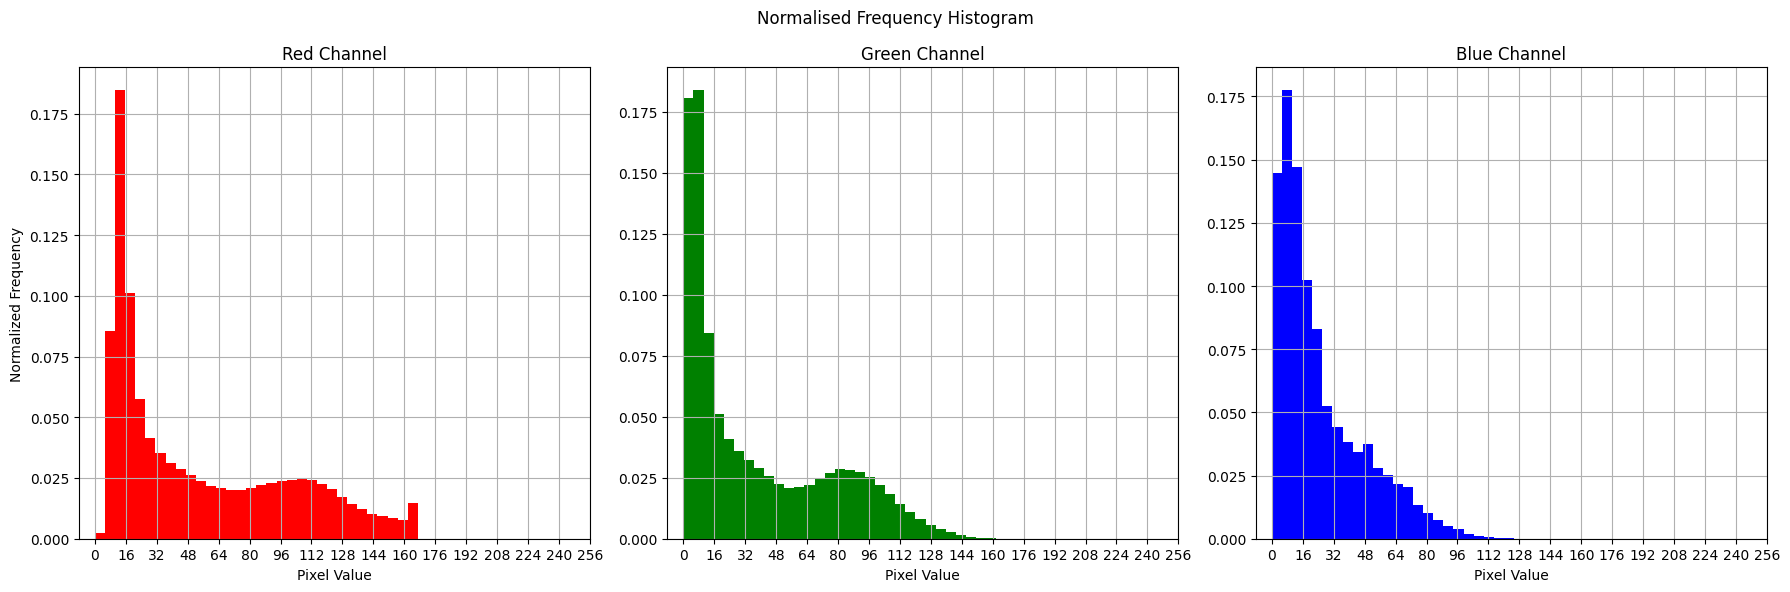

In [5]:
no_of_bins=32

hist_values0, bin_edges = np.histogram(image[:,:,0].flatten(), bins=no_of_bins)
hist_values1, bin_edges = np.histogram(image[:,:,1].flatten(), bins=no_of_bins)
hist_values2, bin_edges = np.histogram(image[:,:,2].flatten(), bins=no_of_bins)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

halfbinwidth=(bin_edges[1]-bin_edges[0])/2

axs[0].bar(bin_edges[:-1]+halfbinwidth, hist_values0 / (image_shape[0] * image_shape[1]), width=2*halfbinwidth, color='red')
axs[0].set_title('Red Channel')
axs[0].set_xlabel('Pixel Value')
axs[0].set_ylabel('Normalized Frequency')
axs[0].grid(True)

axs[1].bar(bin_edges[:-1]+halfbinwidth, hist_values1 / (image_shape[0] * image_shape[1]), width=2*halfbinwidth, color='green')
axs[1].set_title('Green Channel')
axs[1].set_xlabel('Pixel Value')
axs[1].grid(True)

axs[2].bar(bin_edges[:-1]+halfbinwidth, hist_values2 / (image_shape[0] * image_shape[1]), width=2*halfbinwidth, color='blue')
axs[2].set_title('Blue Channel')
axs[2].set_xlabel('Pixel Value')
axs[2].grid(True)

for ax in axs:
    ax.set_xticks(range(0, 272, 16))
    ax.set_xticklabels(range(0, 272, 16))

fig.suptitle('Normalised Frequency Histogram')
plt.tight_layout()

plt.savefig('normalised_histograms.png')
plt.show()